# 07 — HMER Inference: Handwritten Image → LaTeX

This notebook loads the **best checkpoint produced by `05_training.ipynb`**, uses the canonical vocabulary, and predicts a LaTeX token sequence for one handwritten mathematical expression image.

It reuses the same baseline CNN encoder + LSTM decoder architecture, image preprocessing (grayscale, height 128, preserve aspect ratio, values scaled to `[0, 1]`), and vocabulary saved by the training pipeline.

**Before running:** execute the cells from top to bottom. Set `INPUT_IMAGE_PATH` in the configuration cell to the image you want to recognize.

## 1. Imports

In [2]:
from pathlib import Path
import json
import math

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from IPython.display import display, Markdown

## 2. Project paths and configuration

In [4]:
print(Path.cwd().resolve().parent)

/data1/students/abhista/HMER


In [14]:
# Works when the notebook is launched from either the project root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "crohme2019"
IMAGE_ROOT = PROCESSED_ROOT / "images"
METADATA_ROOT = PROCESSED_ROOT / "metadata"
VOCAB_PATH = METADATA_ROOT / "vocab.json"

MODEL_PATH = PROJECT_ROOT / "outputs" / "models" / "baseline_hmer_best.pt"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "predictions"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

IMAGE_HEIGHT = 128
MAX_IMAGE_WIDTH = 1024
MAX_DECODE_LENGTH = 150

# Change this to the path of your handwritten expression image.
# Example: PROJECT_ROOT / "data" / "processed" / "crohme2019" / "images" / "test" / "some_image.png"
INPUT_IMAGE_PATH = PROJECT_ROOT / "data" / "test.jpeg"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Project root :", PROJECT_ROOT)
print("Checkpoint   :", MODEL_PATH)
print("Device       :", DEVICE)
assert MODEL_PATH.exists(), (
    f"Checkpoint not found: {MODEL_PATH}\n"
    "Confirm that 05_training.ipynb saved outputs/models/baseline_hmer_best.pt."
)

Project root : /data1/students/abhista/HMER
Checkpoint   : /data1/students/abhista/HMER/outputs/models/baseline_hmer_best.pt
Device       : cuda


## 3. Load checkpoint and vocabulary

In [7]:
# weights_only=False is needed for checkpoints containing metadata dictionaries
# on PyTorch versions where weights_only defaults to True. Only load your own trusted checkpoint.
try:
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
except TypeError:
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

if not isinstance(checkpoint, dict) or "model_state_dict" not in checkpoint:
    raise ValueError(
        "Unexpected checkpoint format. Expected a dictionary containing 'model_state_dict'."
    )

# Prefer the exact vocabulary embedded in the training checkpoint.
if "token_to_id" in checkpoint and "id_to_token" in checkpoint:
    token_to_id = {str(k): int(v) for k, v in checkpoint["token_to_id"].items()}
    id_to_token = {int(k): str(v) for k, v in checkpoint["id_to_token"].items()}
else:
    if not VOCAB_PATH.exists():
        raise FileNotFoundError(
            f"Vocabulary not found in checkpoint or at {VOCAB_PATH}"
        )
    with open(VOCAB_PATH, "r", encoding="utf-8") as file:
        vocab_data = json.load(file)

    if "token_to_id" in vocab_data:
        token_to_id = {str(k): int(v) for k, v in vocab_data["token_to_id"].items()}
    elif "vocabulary" in vocab_data and isinstance(vocab_data["vocabulary"], dict):
        token_to_id = {str(k): int(v) for k, v in vocab_data["vocabulary"].items()}
    else:
        token_to_id = {str(k): int(v) for k, v in vocab_data.items()}

    if "id_to_token" in vocab_data:
        id_to_token = {int(k): str(v) for k, v in vocab_data["id_to_token"].items()}
    else:
        id_to_token = {idx: token for token, idx in token_to_id.items()}

PAD_ID = token_to_id["<PAD>"]
SOS_ID = token_to_id["<SOS>"]
EOS_ID = token_to_id["<EOS>"]
UNK_ID = token_to_id["<UNK>"]
VOCAB_SIZE = len(token_to_id)

config = checkpoint.get("config", {})
EMBEDDING_DIM = int(config.get("embedding_dim", 256))
HIDDEN_DIM = int(config.get("hidden_dim", 512))
NUM_LAYERS = int(config.get("num_layers", 1))
DROPOUT = float(config.get("dropout", 0.0))
IMAGE_HEIGHT = int(config.get("image_height", IMAGE_HEIGHT))
MAX_IMAGE_WIDTH = int(config.get("max_image_width", MAX_IMAGE_WIDTH))

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Checkpoint epoch: {checkpoint.get('epoch', 'not recorded')}")
print(f"Best validation loss: {checkpoint.get('valid_loss', 'not recorded')}")
print(f"Special IDs — PAD: {PAD_ID}, SOS: {SOS_ID}, EOS: {EOS_ID}, UNK: {UNK_ID}")

Vocabulary size: 121
Checkpoint epoch: 1
Best validation loss: 2.590343120166794
Special IDs — PAD: 0, SOS: 1, EOS: 2, UNK: 3


## 4. Define the same baseline architecture

In [8]:
class CNNEncoder(nn.Module):
    def __init__(self, hidden_dim=512):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.projection = nn.Linear(512, hidden_dim)

    def forward(self, images):
        features = self.features(images)
        return self.projection(features.flatten(1))


class LSTMDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=256,
        hidden_dim=512,
        num_layers=1,
        dropout=0.0,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_ID,
        )
        self.image_to_hidden = nn.Linear(
            hidden_dim, num_layers * hidden_dim
        )
        self.image_to_cell = nn.Linear(
            hidden_dim, num_layers * hidden_dim
        )
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.output_projection = nn.Linear(hidden_dim, vocab_size)

    def initialize_state(self, image_features):
        batch_size = image_features.size(0)
        hidden = self.image_to_hidden(image_features).view(
            self.num_layers, batch_size, self.hidden_dim
        )
        cell = self.image_to_cell(image_features).view(
            self.num_layers, batch_size, self.hidden_dim
        )
        return hidden, cell

    def forward(self, image_features, target_sequences):
        embedded = self.embedding(target_sequences)
        hidden, cell = self.initialize_state(image_features)
        outputs, _ = self.lstm(embedded, (hidden, cell))
        return self.output_projection(outputs)


class BaselineHMER(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=256,
        hidden_dim=512,
        num_layers=1,
        dropout=0.0,
    ):
        super().__init__()
        self.encoder = CNNEncoder(hidden_dim=hidden_dim)
        self.decoder = LSTMDecoder(
            vocab_size=vocab_size,
            embedding_dim=embedding_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
        )

    def forward(self, images, target_sequences):
        image_features = self.encoder(images)
        return self.decoder(image_features, target_sequences)

## 5. Load trained weights

In [9]:
model = BaselineHMER(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

model.load_state_dict(checkpoint["model_state_dict"], strict=True)
model.eval()

print("Trained model loaded successfully.")
print(
    "Trainable parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

Trained model loaded successfully.
Trainable parameters: 4,027,961


## 6. Image preprocessing and autoregressive decoding

In [10]:
def preprocess_image(image_path):
    """Apply the same grayscale/height/width/value scaling as training."""
    image_path = Path(image_path).expanduser()
    if not image_path.exists():
        raise FileNotFoundError(f"Input image not found: {image_path}")

    with Image.open(image_path) as opened:
        image = opened.convert("L")
        original_width, original_height = image.size

        if original_height <= 0 or original_width <= 0:
            raise ValueError(f"Invalid image dimensions: {image.size}")

        if original_height != IMAGE_HEIGHT:
            scale = IMAGE_HEIGHT / original_height
            new_width = max(1, round(original_width * scale))
            image = image.resize(
                (new_width, IMAGE_HEIGHT),
                Image.Resampling.BILINEAR,
            )

        if image.width > MAX_IMAGE_WIDTH:
            raise ValueError(
                f"Image width after resizing is {image.width}px, exceeding "
                f"MAX_IMAGE_WIDTH={MAX_IMAGE_WIDTH}. Crop or resize the image "
                "without distorting the expression, then try again."
            )

        array = np.asarray(image, dtype=np.float32) / 255.0

    tensor = torch.from_numpy(array).unsqueeze(0).unsqueeze(0)
    return image.copy(), tensor.to(DEVICE)


def decode_token_ids(token_ids):
    """Convert predicted token IDs to the project's space-separated token format."""
    tokens = []
    for token_id in token_ids:
        if token_id == EOS_ID:
            break
        if token_id in (PAD_ID, SOS_ID):
            continue
        tokens.append(id_to_token.get(int(token_id), "<UNK>"))
    return " ".join(tokens)


@torch.inference_mode()
def predict_image(image_path, max_length=MAX_DECODE_LENGTH):
    """Greedy autoregressive prediction for one handwritten expression image."""
    pil_image, image_tensor = preprocess_image(image_path)

    image_features = model.encoder(image_tensor)
    hidden, cell = model.decoder.initialize_state(image_features)

    current_token = torch.tensor([[SOS_ID]], dtype=torch.long, device=DEVICE)
    predicted_ids = []

    for _ in range(max_length):
        embedded = model.decoder.embedding(current_token)
        output, (hidden, cell) = model.decoder.lstm(
            embedded, (hidden, cell)
        )
        logits = model.decoder.output_projection(output[:, -1, :])
        next_token = int(torch.argmax(logits, dim=-1).item())

        if next_token == EOS_ID:
            break

        # Guard against emitting control tokens as ordinary expression symbols.
        if next_token not in (PAD_ID, SOS_ID):
            predicted_ids.append(next_token)

        current_token = torch.tensor(
            [[next_token]], dtype=torch.long, device=DEVICE
        )

    predicted_tokens = decode_token_ids(predicted_ids)
    return {
        "image": pil_image,
        "image_tensor": image_tensor,
        "token_ids": predicted_ids,
        "tokens": predicted_tokens,
        "image_path": str(Path(image_path).expanduser().resolve()),
    }

## 7. Run inference on an image

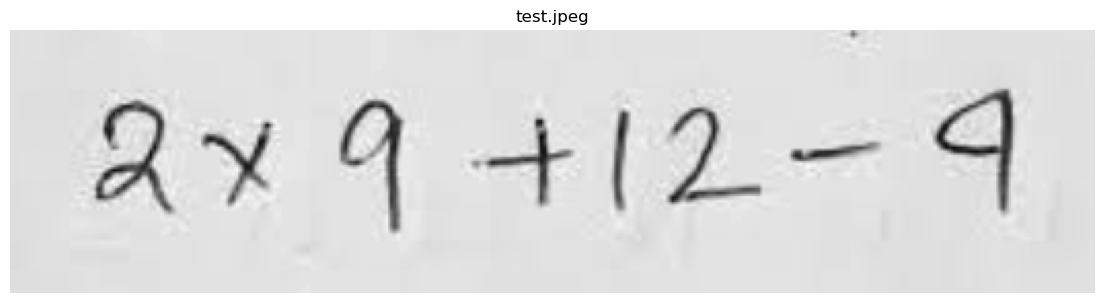

Input image: /data1/students/abhista/HMER/data/test.jpeg
Predicted token IDs: [20, 4, 60, 5]
Predicted LaTeX tokens:
\mbox { j }


**Predicted expression (LaTeX):**

$$
\mbox { j }
$$

In [15]:
# Edit INPUT_IMAGE_PATH in Section 2 before running this cell.
result = predict_image(INPUT_IMAGE_PATH)

plt.figure(figsize=(14, 4))
plt.imshow(result["image"], cmap="gray")
plt.axis("off")
plt.title(Path(result["image_path"]).name)
plt.show()

print("Input image:", result["image_path"])
print("Predicted token IDs:", result["token_ids"])
print("Predicted LaTeX tokens:")
print(result["tokens"])

# IPython/Jupyter may render the mathematical expression if MathJax supports its commands.
display(Markdown("**Predicted expression (LaTeX):**\n\n$$\n" + result["tokens"] + "\n$$"))

## 8. Save the prediction

In [ ]:
prediction_path = OUTPUT_ROOT / (
    Path(result["image_path"]).stem + "_prediction.json"
)

prediction = {
    "image_path": result["image_path"],
    "checkpoint_path": str(MODEL_PATH),
    "checkpoint_epoch": checkpoint.get("epoch"),
    "predicted_token_ids": result["token_ids"],
    "predicted_latex_tokens": result["tokens"],
}

with open(prediction_path, "w", encoding="utf-8") as file:
    json.dump(prediction, file, indent=2, ensure_ascii=False)

print("Saved prediction to:", prediction_path)

## Notes and limitations

- This notebook uses **greedy decoding**: it chooses the highest-probability token at each step. It does not use beam search.
- The current baseline compresses the entire image to a single feature vector before decoding and has no spatial attention. This limits its ability to represent two-dimensional mathematical structure.
- The output follows the project's tokenized LaTeX convention, with spaces between vocabulary tokens. It may need token-aware post-processing before being used as conventional LaTeX source.
- If you use a new photo or scan, crop it to the expression and ensure its contrast/background resembles the preprocessed training images.
- This notebook loads the trained model and does **not** retrain it.